## **<font color="red">Polynomial Regression</font>**
### **Linear Regression**

Training samples: 64, Test samples: 16

Train R²: 0.7478, Train MSE: 338.8234
Test  R²: 0.7863, Test  MSE: 312.3776

Learned model:
y = -4.7444 + (8.6194)*x^1 + (-1.1728)*x^2 + (1.6293)*x^3


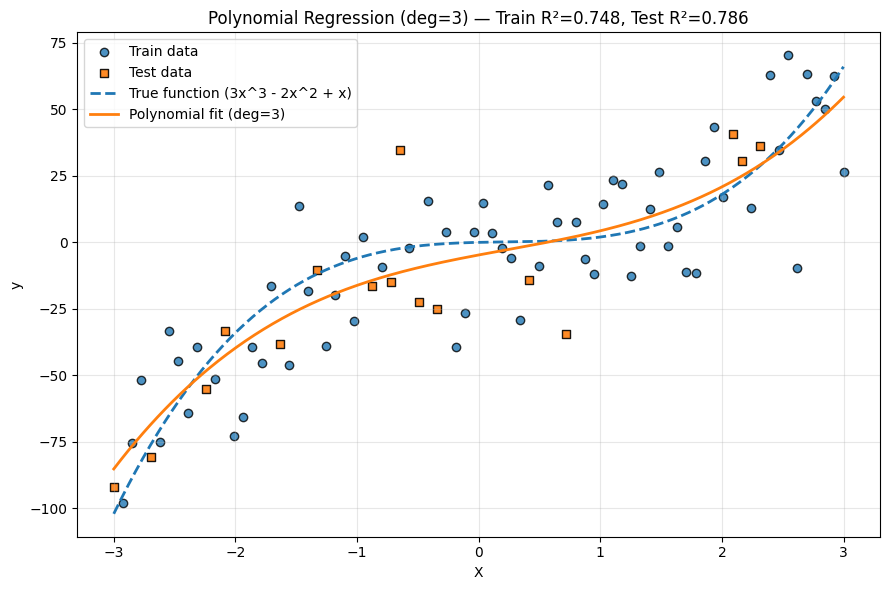

In [5]:
# Polynomial regression with proper train/test split (step-wise)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Generate synthetic dataset
# -----------------------------
np.random.seed(42)

# Inputs
X = np.linspace(-3, 3, 80).reshape(-1, 1)    # shape (80,1)

# True cubic function
true_y = (3 * X**3 - 2 * X**2 + X).ravel()  # ravel -> shape (80,)

# Add stronger Gaussian noise
noise = np.random.normal(0, 20, size=X.shape).ravel()
y = true_y + noise                           # final observations (80,)

# -----------------------------
# 2. Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -----------------------------
# 3. Polynomial features (fit on train only)
# -----------------------------
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)

# Fit transformer on training data, then transform both train and test
X_train_poly = poly.fit_transform(X_train)   # shape (n_train, degree)
X_test_poly = poly.transform(X_test)         # shape (n_test, degree)

# -----------------------------
# 4. Fit LinearRegression on polynomial features
# -----------------------------
model = LinearRegression()
model.fit(X_train_poly, y_train)

# -----------------------------
# 5. Predictions & Metrics (train & test)
# -----------------------------
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"\nTrain R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}")
print(f"Test  R²: {r2_test:.4f}, Test  MSE: {mse_test:.4f}")

# -----------------------------
# 6. Model equation (human-readable)
# -----------------------------
intercept = float(model.intercept_)
coefs = model.coef_.tolist()  # coefs correspond to x^1, x^2, ..., x^degree (since include_bias=False)

terms = " + ".join([f"({coefs[i]:.4f})*x^{i+1}" for i in range(len(coefs))])
print("\nLearned model:")
print(f"y = {intercept:.4f} + {terms}")

# -----------------------------
# 7. Visualization
# -----------------------------
plt.figure(figsize=(9, 6))

# Create a dense X for smooth plotting of true function and model prediction
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
true_y_plot = (3 * X_plot**3 - 2 * X_plot**2 + X_plot).ravel()

# Transform X_plot using the same poly transformer
X_plot_poly = poly.transform(X_plot)
y_plot_pred = model.predict(X_plot_poly)

# Plot train/test points
plt.scatter(X_train, y_train, label="Train data", marker="o", edgecolor="k", alpha=0.8)
plt.scatter(X_test, y_test, label="Test data", marker="s", edgecolor="k", alpha=0.9)

# Plot true function and model prediction curve
plt.plot(X_plot, true_y_plot, label="True function (3x^3 - 2x^2 + x)", linewidth=2, linestyle="--")
plt.plot(X_plot, y_plot_pred, label=f"Polynomial fit (deg={degree})", linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Regression (deg={degree}) — Train R²={r2_train:.3f}, Test R²={r2_test:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


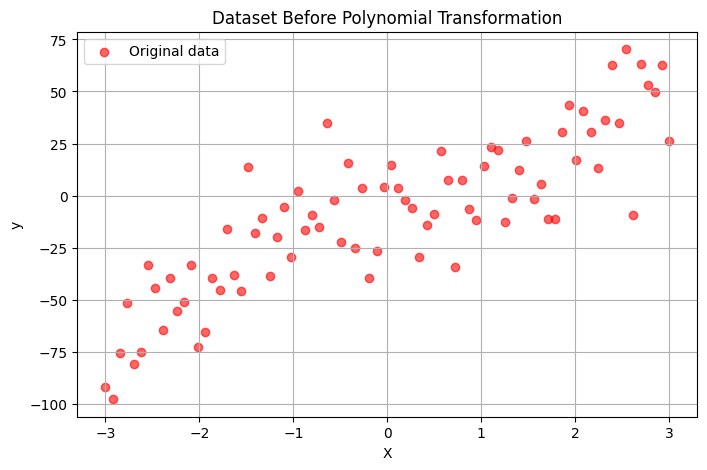

Training samples: 64, Test samples: 16


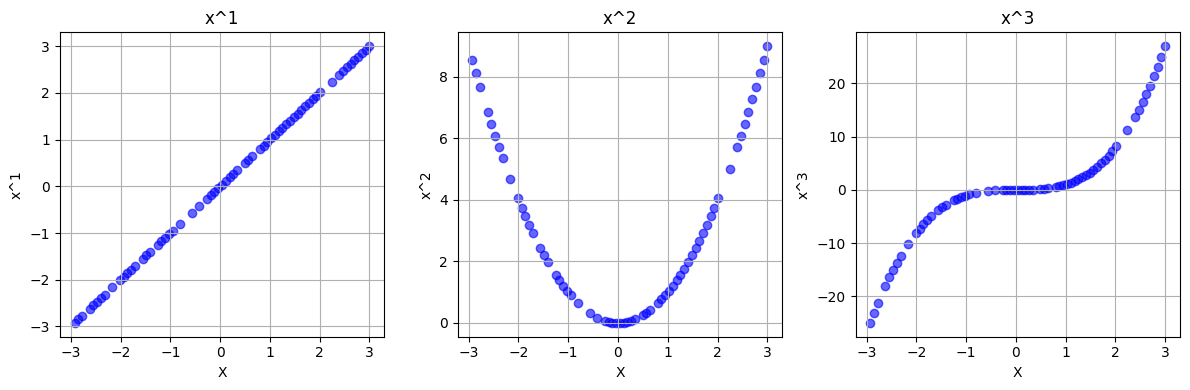


Train R²: 0.7478, Train MSE: 338.8234
Test  R²: 0.7863, Test  MSE: 312.3776

Learned model:
y = -4.7444 + (8.6194)*x^1 + (-1.1728)*x^2 + (1.6293)*x^3


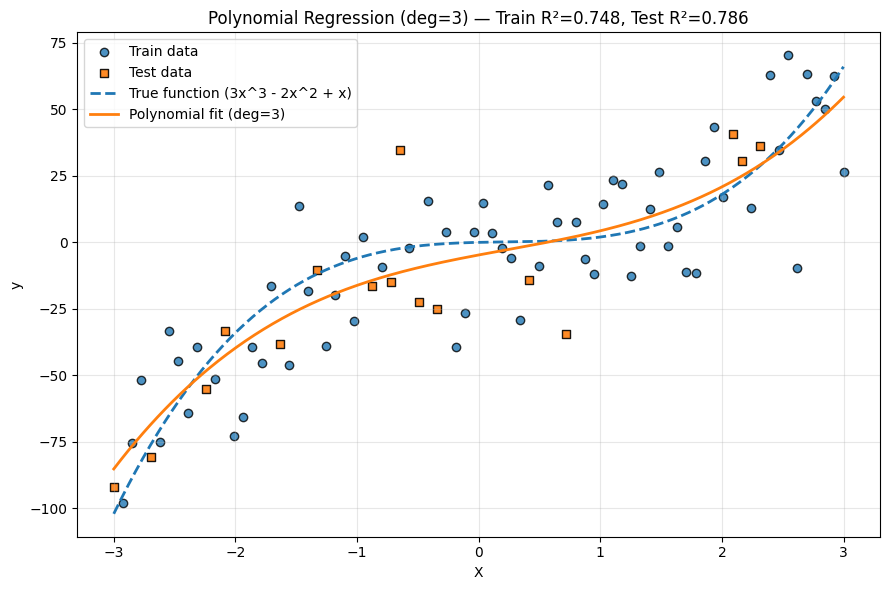

In [13]:
# Polynomial regression with visualization of dataset before and after transformation
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

# -----------------------------
# 1. Generate synthetic dataset
# -----------------------------
np.random.seed(42)
X = np.linspace(-3, 3, 80).reshape(-1, 1)
true_y = (3 * X**3 - 2 * X**2 + X).ravel()
noise = np.random.normal(0, 20, size=X.shape).ravel()
y = true_y + noise

# -----------------------------
# 2. Plot dataset before transformation
# -----------------------------
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='red', alpha=0.6, label='Original data')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dataset Before Polynomial Transformation")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------
# 3. Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, shuffle=True
)
print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -----------------------------
# 4. Polynomial features (fit on train only)
# -----------------------------
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# -----------------------------
# 5. Plot polynomial features after transformation
# -----------------------------
feature_names = [f"x^{i+1}" for i in range(X_train_poly.shape[1])]
plt.figure(figsize=(12, 4))
for i in range(X_train_poly.shape[1]):
    plt.subplot(1, X_train_poly.shape[1], i+1)
    plt.scatter(X_train, X_train_poly[:, i], alpha=0.6, color='blue')
    plt.xlabel("X")
    plt.ylabel(feature_names[i])
    plt.title(feature_names[i])
    plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Fit LinearRegression on polynomial features
# -----------------------------
model = LinearRegression()
model.fit(X_train_poly, y_train)

# -----------------------------
# 7. Predictions & Metrics (train & test)
# -----------------------------
y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"\nTrain R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}")
print(f"Test  R²: {r2_test:.4f}, Test  MSE: {mse_test:.4f}")

# -----------------------------
# 8. Model equation (human-readable)
# -----------------------------
intercept = float(model.intercept_)
coefs = model.coef_.tolist()
terms = " + ".join([f"({coefs[i]:.4f})*x^{i+1}" for i in range(len(coefs))])
print("\nLearned model:")
print(f"y = {intercept:.4f} + {terms}")

# -----------------------------
# 9. Visualization of fit
# -----------------------------
plt.figure(figsize=(9, 6))
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
true_y_plot = (3 * X_plot**3 - 2 * X_plot**2 + X_plot).ravel()
X_plot_poly = poly.transform(X_plot)
y_plot_pred = model.predict(X_plot_poly)

# Plot train/test points
plt.scatter(X_train, y_train, label="Train data", marker="o", edgecolor="k", alpha=0.8)
plt.scatter(X_test, y_test, label="Test data", marker="s", edgecolor="k", alpha=0.9)

# Plot true function and model prediction curve
plt.plot(X_plot, true_y_plot, label="True function (3x^3 - 2x^2 + x)", linewidth=2, linestyle="--")
plt.plot(X_plot, y_plot_pred, label=f"Polynomial fit (deg={degree})", linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Regression (deg={degree}) — Train R²={r2_train:.3f}, Test R²={r2_test:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### **Ridge Regression**

Train R²: 0.6026, Train MSE: 326.4247
Test  R²: 0.6726, Test  MSE: 240.5542


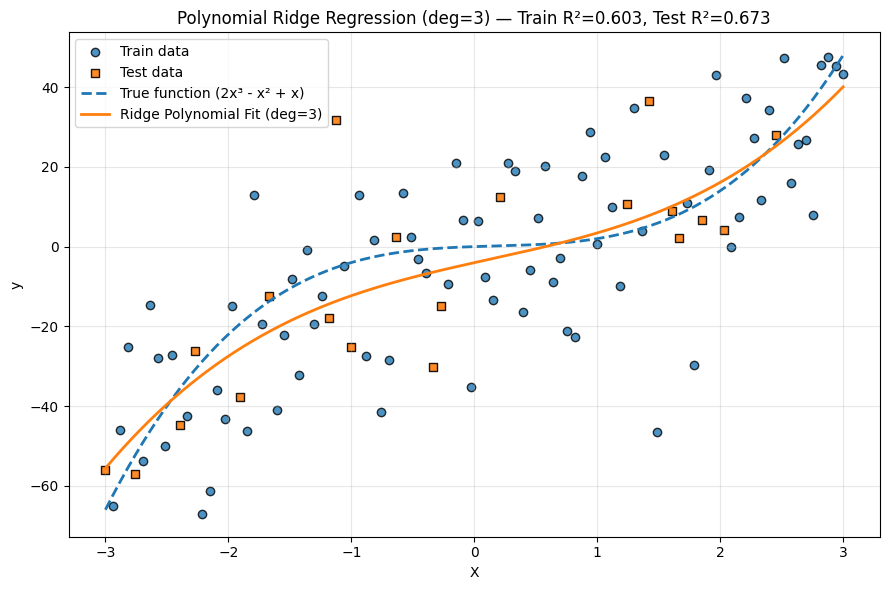

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# 1. Generate nonlinear data
# -----------------------------
np.random.seed(42)
X = np.linspace(-3, 3, 100).reshape(-1,1)

# True cubic function
true_y = 2*X**3 - X**2 + X

# Add Gaussian noise
noise = np.random.normal(0, 20, size=X.shape)
y = true_y + noise

# -----------------------------
# 2. Split dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Polynomial transformation
# -----------------------------
degree = 3
poly = PolynomialFeatures(degree=degree, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# -----------------------------
# 4. Train Ridge Regression
# -----------------------------
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_poly, y_train)

# -----------------------------
# 5. Predictions & Metrics
# -----------------------------
y_train_pred = ridge.predict(X_train_poly)
y_test_pred = ridge.predict(X_test_poly)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print(f"Train R²: {r2_train:.4f}, Train MSE: {mse_train:.4f}")
print(f"Test  R²: {r2_test:.4f}, Test  MSE: {mse_test:.4f}")

# -----------------------------
# 6. Visualization
# -----------------------------
plt.figure(figsize=(9, 6))

# Dense X for smooth plotting
X_plot = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)
X_plot_poly = poly.transform(X_plot)

# True function (without noise)
true_y_plot = (2*X_plot**3 - X_plot**2 + X_plot).ravel()

# Model prediction
y_plot_pred = ridge.predict(X_plot_poly)

# Plot train/test points
plt.scatter(X_train, y_train, label="Train data", marker="o", edgecolor="k", alpha=0.8)
plt.scatter(X_test, y_test, label="Test data", marker="s", edgecolor="k", alpha=0.9)

# Plot true function and model prediction curve
plt.plot(X_plot, true_y_plot, label="True function (2x³ - x² + x)", linewidth=2, linestyle="--")
plt.plot(X_plot, y_plot_pred, label=f"Ridge Polynomial Fit (deg={degree})", linewidth=2)

plt.xlabel("X")
plt.ylabel("y")
plt.title(f"Polynomial Ridge Regression (deg={degree}) — Train R²={r2_train:.3f}, Test R²={r2_test:.3f}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### **<font color="blue">Compare with Linear Regression</font>**

Train samples: 75, Test samples: 25
Linear Regression -> Train R²: 0.0707, Test R²: -0.4878
Poly (deg=2) -> Train R²: 0.3915, Test R²: 0.1206

Linear model: y = 28.0079 + 2.6783 * x
Polynomial model coefficients (intercept + coefs):
intercept = -9.6536
  x^1: 2.3426
  x^2: 1.0782


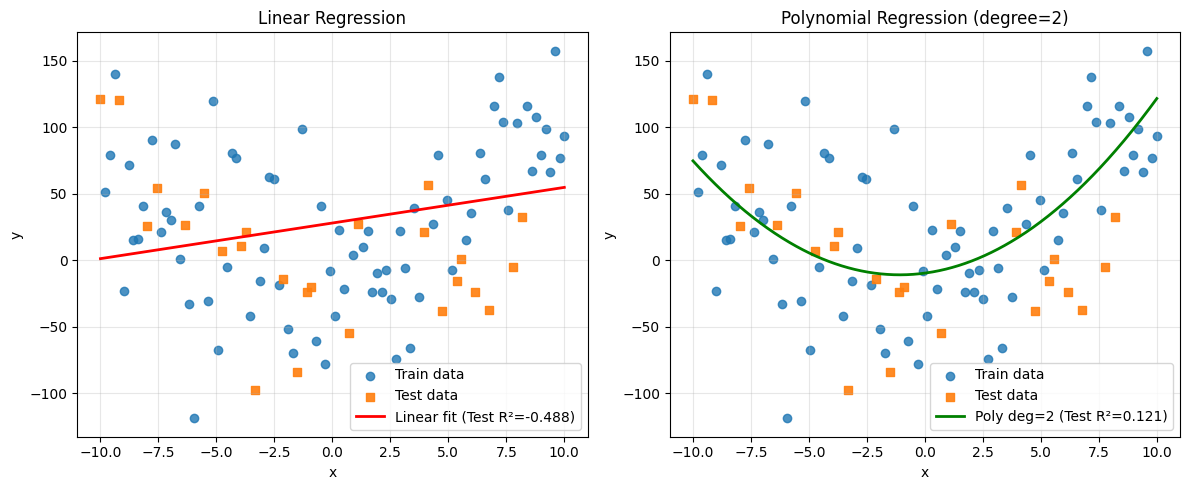

In [7]:
# Corrected: train/test split + step-wise polynomial (no make_pipeline)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# -------------------------
# 0. Reproducibility
# -------------------------
np.random.seed(0)

# -------------------------
# 1. Generate dataset
# -------------------------
x = np.linspace(-10, 10, 100)                      # shape (100,)
y = 3 + 2 * x + 0.5 * x**2 + np.random.normal(0, 50, 100)  # shape (100,)

# Reshape to (n_samples, n_features)
X = x.reshape(-1, 1)                               # shape (100,1)

# -------------------------
# 2. Train / Test split
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, shuffle=True
)
print(f"Train samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -------------------------
# 3. Linear Regression (fit on train only)
# -------------------------
lin = LinearRegression()
lin.fit(X_train, y_train)

y_test_pred_lin = lin.predict(X_test)

r2_train_lin = r2_score(y_train, y_train_pred_lin)
r2_test_lin = r2_score(y_test, y_test_pred_lin)
print(f"Linear Regression -> Train R²: {r2_train_lin:.4f}, Test R²: {r2_test_lin:.4f}")

# -------------------------
# 4. Polynomial Regression (degree=2) - step-wise
# -------------------------
degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)

# Fit transformer on training X then transform both train and test
X_train_poly = poly.fit_transform(X_train)   # columns: [x, x^2]
X_test_poly = poly.transform(X_test)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

y_test_pred_poly = poly_model.predict(X_test_poly)

r2_train_poly = r2_score(y_train, y_train_pred_poly)
r2_test_poly = r2_score(y_test, y_test_pred_poly)
print(f"Poly (deg={degree}) -> Train R²: {r2_train_poly:.4f}, Test R²: {r2_test_poly:.4f}")

# -------------------------
# 5. Model equations
# -------------------------
print("\nLinear model: y = {:.4f} + {:.4f} * x".format(lin.intercept_, lin.coef_[0]))
coef_names = ["x^1", "x^2"]
print("Polynomial model coefficients (intercept + coefs):")
print("intercept = {:.4f}".format(poly_model.intercept_))
for name, c in zip(coef_names, poly_model.coef_):
    print(f"  {name}: {c:.4f}")

# -------------------------
# 6. Visualization
# -------------------------
plt.figure(figsize=(12, 5))

# Prepare a dense X for smooth model curves
X_plot = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)

# Linear predictions for plot
y_plot_lin = lin.predict(X_plot)

# Polynomial predictions for plot (remember to transform)
X_plot_poly = poly.transform(X_plot)
y_plot_poly = poly_model.predict(X_plot_poly)

# Subplot 1: Linear
plt.subplot(1, 2, 1)
plt.scatter(X_train, y_train, label="Train data", marker="o", alpha=0.8)
plt.scatter(X_test, y_test, label="Test data", marker="s", alpha=0.9)
plt.plot(X_plot, y_plot_lin, color="red", linewidth=2, label=f"Linear fit (Test R²={r2_test_lin:.3f})")
plt.title("Linear Regression")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: Polynomial (degree=2)
plt.subplot(1, 2, 2)
plt.scatter(X_train, y_train, label="Train data", marker="o", alpha=0.8)
plt.scatter(X_test, y_test, label="Test data", marker="s", alpha=0.9)
plt.plot(X_plot, y_plot_poly, color="green", linewidth=2,
         label=f"Poly deg={degree} (Test R²={r2_test_poly:.3f})")
plt.title(f"Polynomial Regression (degree={degree})")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## **<font color="green">Generate a Vandermonde matrix</font>**

In [31]:
x = np.array([1, 2, 3, 4, 5])
N = 8
np.vander(x, N)

array([[    1,     1,     1,     1,     1,     1,     1,     1],
       [  128,    64,    32,    16,     8,     4,     2,     1],
       [ 2187,   729,   243,    81,    27,     9,     3,     1],
       [16384,  4096,  1024,   256,    64,    16,     4,     1],
       [78125, 15625,  3125,   625,   125,    25,     5,     1]])

In [32]:
x = np.array([1, 2, 3, 4, 5])
N = 8
np.vander(x, N, increasing=True)

array([[    1,     1,     1,     1,     1,     1,     1,     1],
       [    1,     2,     4,     8,    16,    32,    64,   128],
       [    1,     3,     9,    27,    81,   243,   729,  2187],
       [    1,     4,    16,    64,   256,  1024,  4096, 16384],
       [    1,     5,    25,   125,   625,  3125, 15625, 78125]])

In [34]:
import numpy as np

x = np.array([[1, 2, 3, 4, 5],
              [5, 6, 7, 8, 9]])
N = 5

vander_matrices = np.array([np.vander(row, N, increasing=True) for row in x])
print(vander_matrices)


[[[   1    1    1    1    1]
  [   1    2    4    8   16]
  [   1    3    9   27   81]
  [   1    4   16   64  256]
  [   1    5   25  125  625]]

 [[   1    5   25  125  625]
  [   1    6   36  216 1296]
  [   1    7   49  343 2401]
  [   1    8   64  512 4096]
  [   1    9   81  729 6561]]]
